# Deep Research Agent

Runs the deep-research pipeline end to end. The full graph is assembled in `deep_research/tools/agent_builder.py` from the following modules:

1. **`write_research_brief`** (`deep_research/agents/draft_agent.py`) — generates a research brief from the user's question
2. **`write_draft_report`** (same module) — generates a draft report from the research brief
3. **`supervisor_agent`** (`deep_research/agents/supervisor.py`) — supervisor subgraph: dispatches research agents to search in parallel, revises the draft via `refine_draft_report`, scores it with the Evaluator, and runs Red Team adversarial review
4. **`final_report_generation`** (`deep_research/tools/agent_builder.py`) — writes the final report from the research notes and the draft, using `FINAL_REPORT_PROMPT` + the writer model

Model and search settings are read from `config.yml` at the project root (no `.env` needed).

In [1]:
from importlib.metadata import version, PackageNotFoundError
for pkg in ["langchain", "langgraph", "langchain-openai", "langchain-core", "tavily"]:
    try:
        print(f"{pkg} version: ", version(pkg))
    except PackageNotFoundError:
        print(f"{pkg}: NOT INSTALLED")

langchain version:  1.3.11
langgraph version:  1.2.8
langchain-openai version:  1.3.5
langchain-core version:  1.4.9
tavily version:  1.1.0


In [2]:
import os

from deep_research.observability import configure_langsmith

if configure_langsmith():
    print(f"LangSmith tracing enabled (project: {os.environ['LANGSMITH_PROJECT']})")
else:
    print("LangSmith tracing disabled (no LANGSMITH_API_KEY in .env)")

LangSmith tracing enabled (project: deep-research)


## Build the full pipeline graph

Import the pre-assembled graph builder from `agent_builder` (which defines the `final_report_generation` writer node) and compile it with an in-memory checkpointer.

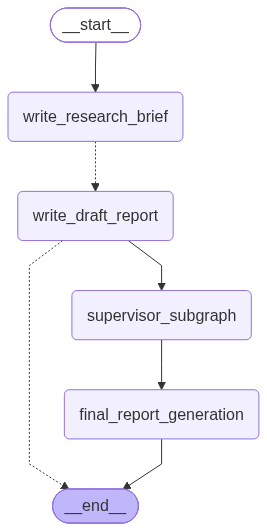

In [4]:
import warnings
warnings.filterwarnings("ignore")

from IPython.display import Image, display
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

from deep_research.tools.agent_builder import deep_researcher_builder

checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(full_agent.get_graph(xray=True).draw_mermaid_png()))

## Run the research

The full pipeline takes about 10–20 minutes (multiple search rounds + draft revisions + adversarial review).

In [5]:
import uuid

# Fresh thread per run: reusing a thread_id makes `messages` accumulate across runs
# (add_messages reducer + checkpointer), which can leak earlier questions into the
# prompt history and e.g. flip the report language.
thread = {"configurable": {"thread_id": str(uuid.uuid4())}, "recursion_limit": 50}

result = await full_agent.ainvoke(
    {"messages": [HumanMessage(content="I'm an AI product manager considering adding a personalized memory feature to our product. I'd like a systematic overview of where Memory modules in agents are heading, including how short-term and long-term memory are implemented, and the differences and trade-offs between the various technical approaches. Please write me a research report analyzing, from the perspectives of engineering feasibility and future evolution, which directions are most worth investing in.")]},
    config=thread,
)

2026-07-19 15:20:53,015 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-07-19 15:21:41,415 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-07-19 15:21:41,429 - deep_research.agents.supervisor - INFO - [SUPERVISOR] supervisor invoked (iteration=0, messages=2)
2026-07-19 15:21:45,914 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-07-19 15:21:45,920 - deep_research.agents.supervisor - INFO - supervisor model produced tool_calls=True num_tool_calls=1
2026-07-19 15:21:45,922 - deep_research.agents.supervisor - INFO - [SUPERVISOR] supervisor_tools executing think=1 conduct=0 refine=0
2026-07-19 15:21:45,925 - deep_research.agents.supervisor - INFO - [SUPERVISOR] supervisor invoked (iteration=1, messages=4)
2026-07-19 15:21:51,448 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-0

In [6]:
from rich.console import Console
from rich.markdown import Markdown

console = Console()
console.print(Markdown(result["final_report"]))

Research Report: Where “Memory” Modules in Agentic AI Systems Are Heading                     

Executive Summary                                                                                                  

Memory in agentic AI is moving from a convenience feature into a core product and infrastructure layer. The early  
pattern was simple: persist chat history, embed it, retrieve similar snippets, and place them into the prompt. That
pattern is still useful, but it is no longer sufficient for serious product use. The direction of travel is toward 
governed, multi-representation, source-linked, user-controllable memory systems that combine short-term working    
state, long-term user preferences, event logs, vector retrieval, structured records, summaries, and explicit       
memory-management tools.                                                                                           

For a product feature that provides personalized memory, the strongest investment direction is a hybrid            
architecture rather than a single technique. A robust personalized memory system should use structured profile and 
preference memory for high-value stable facts, an event log as the source of truth, a vector evidence store for    
semantic recall, source-linked summaries for compact context, and policy-gated tools for writing, updating,        
deleting, explaining, and auditing memory. This architecture is more reliable than pure vector memory, more        
controllable than silent summarization, more feasible than a full personal knowledge graph, and far safer than     
storing user-specific memory in model weights.                                                                     

The most important product insight is that remembering more is not the same as remembering better. Personalized    
memory creates value when it is selective, accurate, explainable, correctable, and under user or administrator     
control. It creates risk when it silently persists sensitive details, makes incorrect inferences, retrieves stale  
context, leaks across tenants, or cannot propagate deletion into derived artifacts such as summaries, embeddings,  
caches, and graph edges.                                                                                           

The recommended investment thesis is therefore:                                                                    

                                                                                                                   
 Strategic decision    Recommendation                                                                              
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
 Core architecture     Build a hybrid, tool-gated memory subsystem rather than a vector-only memory layer.         
 First product target  Focus on stable user preferences, communication style, recurring instructions, project      
                       context, and explicit “remember this” facts.                                                
 Source of truth       Use an event log or versioned event records as the authoritative source behind all derived  
                       memories.                                                                                   
 Retrieval role        Use vector retrieval for evidence and recall, not as the sole authoritative profile.        
 User trust            Provide memory settings, view/edit/delete/export, source explanations, and                  
                       temporary/private mode.                                                                     
 Compliance posture    Design deletion propagation, sensitivity classification, retention controls, and            
                       auditability from the start.                                                                
 Near-term investment  Build structured memory, event sourcing, governa

In [7]:
import os
from datetime import datetime

os.makedirs("results", exist_ok=True)
timestamp = datetime.now().strftime("%Y-%m-%d_%H%M%S")

report_path = f"results/report_{timestamp}.md"
with open(report_path, "w") as fd:
    fd.write(result["final_report"])

# Also keep the intermediate artifacts so a run is fully reviewable later
artifacts_path = f"results/artifacts_{timestamp}.md"
with open(artifacts_path, "w") as fd:
    fd.write("# Research Brief\n\n")
    fd.write(result.get("research_brief", "") + "\n\n")
    fd.write("# Draft Report\n\n")
    fd.write(result.get("draft_report", ""))

print(f"Final report saved to {report_path}")
print(f"Brief + draft saved to {artifacts_path}")

Final report saved to results/report_2026-07-19_153849.md
Brief + draft saved to results/artifacts_2026-07-19_153849.md


## Inspect intermediate artifacts (optional)

Check the research brief and the draft report from the final state.

In [8]:
print("===== Research Brief =====")
print(result.get("research_brief", ""))
print()
print("===== Draft Report (head) =====")
print(result.get("draft_report", "")[:2000])

===== Research Brief =====
For my AI product decision-making, I want a systematic research report on where “Memory” modules in agentic AI systems are heading, with primary focus on (1) how short-term (working/session/context) and long-term (user/preference/world) memory are implemented, (2) the technical differences among competing approaches (e.g., retrieval-augmented memory, vector/embedding stores, knowledge graphs, event logs, stateful world models, summarization-based memory, agentic tool-based memory, and hybrid architectures), and (3) engineering feasibility (latency, cost, scalability, reliability, deployment complexity, evaluation/grounding, safety & privacy implications, controllability/user consent, and maintainability). I also want the report to compare the approaches by trade-offs and to project future evolution directions, identifying which directions are most worth investing in for a product feature that provides personalized memory. Please treat any unspecified constrai